# 3. Cubic nonlinearity, and a cutoff pathology in the reference — SM Fig. S5

$H_{\rm int}=-\tfrac{ig}{2}[(a^\dagger)^2a-a^\dagger a^2]$ with $\gamma=2.108$, $\omega=2.153$, $f=1.17+4.617i$. Above $g\approx0.62$ the truncated-Fock steady state itself stops converging in the cutoff, so the two "exact" curves separate while the diagrams track the converged region.

**Part A** runs the calculation; **Part B** regenerates Fig. S5 with `make_figures.py cubic` (seconds).

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_work | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation

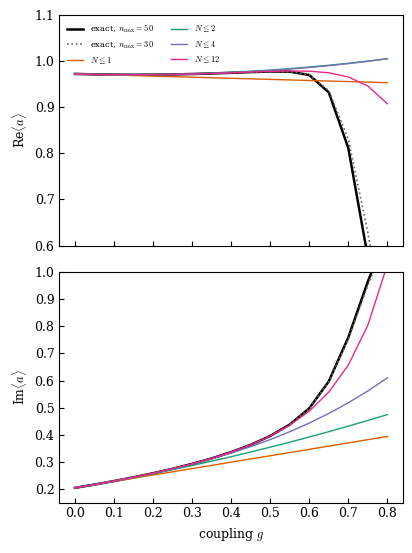

g=0.5: exact 0.977399+0.395675j, series 0.977668+0.395153j


In [2]:
from sparse_ss import steady_sparse
gam, om, f = 2.108, 2.153, 1.17+4.617j
zc = gam/2+1j*om; etac = f/2; alc = etac/zc
a3, ad3, _, _ = mode_ops(alc)
modc = Model(1, zc, lambda X: 0*X, np.eye(1),
             scale(-0.5j, add(mul(mul(ad3,ad3),a3), scale(-1, mul(ad3, mul(a3,a3))))), 3)
Nmc = 12 if FAST else 24
sa = moment_series(modc, 0, 1, alc, Nmc)
gs = np.linspace(0, 0.8, 17 if FAST else 41); cut = (30,50) if FAST else (40,80)
exc = {}
for Ncut in cut:
    A_ = destroy(Ncut); Ad_ = A_.conj().T; v=[]
    for g in gs:
        H = om*Ad_@A_ + 1j*(etac*Ad_-np.conj(etac)*A_) + g*(-0.5j)*(Ad_@Ad_@A_-Ad_@A_@A_)
        v.append(np.trace(A_@steady_sparse(H,[np.sqrt(gam)*A_])))
    exc[Ncut]=np.array(v)
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(4.2,5.6),sharex=True)
for ax,fn,lab in [(ax1,np.real,r'Re$\langle a\rangle$'),(ax2,np.imag,r'Im$\langle a\rangle$')]:
    ax.plot(gs,fn(exc[cut[1]]),'k-',lw=1.8,label=f'exact, $n_{{\\max}}={cut[1]}$')
    ax.plot(gs,fn(exc[cut[0]]),':',color='0.4',lw=1.2,label=f'exact, $n_{{\\max}}={cut[0]}$')
    for c,N in zip(COL,[1,2,4,Nmc]):
        ax.plot(gs,fn([np.sum(sa[:N+1]*g**np.arange(N+1)) for g in gs]),color=c,lw=1,label=f'$N\\leq{N}$')
    ax.set_ylabel(lab)
ax1.legend(fontsize=6,ncol=2); ax2.set_xlabel('coupling $g$'); ax1.set_ylim(0.6,1.1); ax2.set_ylim(0.15,1.0)
fig.tight_layout(); plt.show()
k=np.argmin(abs(gs-0.5)); print(f"g=0.5: exact {exc[cut[1]][k]:.6f}, series {np.sum(sa[:Nmc+1]*0.5**np.arange(Nmc+1)):.6f}")

## Part B — Fig. S5 of the paper

$ (cd code/engines; python3 make_figures.py cubic)   [12.0 s, exit 0]
 ],
 "cubic_cutoffdiff_g0.6": 0.0004774231397530967
}


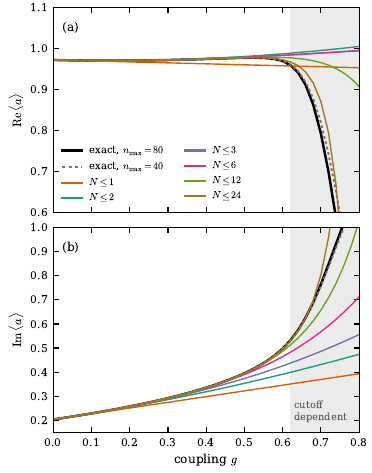

root test |a_N|^(-1/N) at N=10,20,...,60: 1.074, 0.864, 0.789, 0.758, 0.707, 0.664
reference stops converging in the cutoff above g = 0.62
g=0.3: |series - exact| at N=1,3,6,12,24: 1.9e-02, 1.7e-03, 8.4e-05, 3.7e-07, 2.3e-11;  cutoff difference of the reference 7.8e-16
g=0.5: |series - exact| at N=1,3,6,12,24: 7.5e-02, 2.2e-02, 5.4e-03, 5.9e-04, 1.9e-05;  cutoff difference of the reference 1.3e-07
g=0.6: |series - exact| at N=1,3,6,12,24: 1.5e-01, 7.3e-02, 3.6e-02, 1.4e-02, 3.5e-03;  cutoff difference of the reference 4.8e-04


In [3]:
run("python3 make_figures.py cubic", "engines", timeout=600)
paper_figure("engines/fig_cubic_convergence.pdf", width=420)
n = J("engines", "numbers.json")
print(f"root test |a_N|^(-1/N) at N=10,20,...,60: {', '.join(f'{x:.3f}' for x in n['cubic_root_test'])}")
print(f"reference stops converging in the cutoff above g = {n['cubic_gbad']}")
for g in ("0.3", "0.5", "0.6"):
    print(f"g={g}: |series - exact| at N=1,3,6,12,24: " + ", ".join(f"{x:.1e}" for x in n[f'cubic_err_g{g}']) + f";  cutoff difference of the reference {n[f'cubic_cutoffdiff_g{g}']:.1e}")